In [151]:
%reset -f

In [152]:
pos_path = r'C:\Users\thiga\OneDrive\Documents\Masters - Big Data\Year 1\MIT 801\Assignment 2\pos'
neg_path = r'C:\Users\thiga\OneDrive\Documents\Masters - Big Data\Year 1\MIT 801\Assignment 2\neg'

In [153]:
import os
import pandas as pd

In [154]:
data = []

pos_path = "pos"
neg_path = "neg"

# Positive reviews
for file in os.listdir(pos_path):
    if file.endswith(".txt"):
        with open(os.path.join(pos_path, file), 'r', encoding='utf-8') as store:
            data.append({"text": store.read(), "label": 1})

# Negative reviews
for file in os.listdir(neg_path):
    if file.endswith(".txt"):
        with open(os.path.join(neg_path, file), 'r', encoding='utf-8') as store:
            data.append({"text": store.read(), "label": 0})

df = pd.DataFrame(data)

# Shuffle
df = df.sample(frac=1, random_state=30).reset_index(drop=True)

print(df.head())
print()
print(df['label'].value_counts())

                                                text  label
0  burnt money is the perfect festival film . \ni...      0
1  set in the wild west , this carry on centres a...      1
2  and just when you thought joblo was getting a ...      0
3  by starring in amy heckerling's " clueless " t...      0
4  a group of high school kids mix up with a grou...      1

label
0    1000
1    1000
Name: count, dtype: int64


## Stage 1

#### Steps i - iii

In [155]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [156]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    
    #Lowercase
    text = text.lower()
    
    #Tokenise
    tokens = word_tokenize(text)
    
    #Remove stopwords + non-alphabetic
    new_tokens = []
    for i in tokens:
        if i.isalpha() and i not in stop_words:
            new_tokens.append(i)
    tokens = new_tokens
    
    #Lemmatise
    tokens = [lemmatizer.lemmatize(i) for i in tokens]

    #creates strings again
    return " ".join(tokens)

In [157]:
df["cleaned"] = df["text"].apply(preprocess_text)

print("Original Text")
print(df["text"].head())

print("\nPreprocessed Text")
print(df["cleaned"].head())

Original Text
0    burnt money is the perfect festival film . \ni...
1    set in the wild west , this carry on centres a...
2    and just when you thought joblo was getting a ...
3    by starring in amy heckerling's " clueless " t...
4    a group of high school kids mix up with a grou...
Name: text, dtype: object

Preprocessed Text
0    burnt money perfect festival film show twice o...
1    set wild west carry centre around arrival rump...
2    thought joblo getting little soft around corne...
3    starring amy heckerling clueless two summer ag...
4    group high school kid mix group artist documen...
Name: cleaned, dtype: object


#### Step iv

In [158]:
from sklearn.model_selection import train_test_split

x = df["cleaned"]
y = df["label"]

# Create 70% train, 30% temporary split. Function can only create two sets at a time.
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, stratify=y, random_state=30)

# Split remaining 30% into 15% validation and 15% test
x_validation, x_test, y_validation, y_test = train_test_split(x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=30)

In [159]:
print("Train set:")
print(y_train.value_counts())

print("\nValidation set:")
print(y_validation.value_counts())

print("\nTest set:")
print(y_test.value_counts())

Train set:
label
1    700
0    700
Name: count, dtype: int64

Validation set:
label
0    150
1    150
Name: count, dtype: int64

Test set:
label
1    150
0    150
Name: count, dtype: int64


## Stage 2

#### Stage 2i

In [160]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [161]:
max_reviews = 0.95
tfidf = TfidfVectorizer(max_df=max_reviews, min_df=2)

x_train_tfidf = tfidf.fit_transform(x_train) #only fit in training set
x_validation_tfidf = tfidf.transform(x_validation)
x_test_tfidf = tfidf.transform(x_test)

In [162]:
print(len(tfidf.vocabulary_))
print(x_train_tfidf.shape)

17507
(1400, 17507)


#### Stage 2ii

In [163]:
from sentence_transformers import SentenceTransformer

In [164]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [165]:
x_train_emb = model.encode(x_train.tolist())
x_val_emb = model.encode(x_validation.tolist())
x_test_emb = model.encode(x_test.tolist())

In [166]:
print(x_train_emb.shape)

(1400, 384)


## Stage 3

In [167]:
import time
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import f1_score, roc_auc_score

In [168]:
def linear_svm(name, penalty, C):
    
    start_time = time.time()

    model = LinearSVC(penalty=penalty, C=C, dual=False, max_iter=5000, random_state=30)
    model.fit(x_train_tfidf, y_train)

    train_time = time.time() - start_time

    y_validation_predict = model.predict(x_validation_tfidf)
    y_validation_scores = model.decision_function(x_validation_tfidf)

    validation_f1 = f1_score(y_validation, y_validation_predict)
    validation_auc = roc_auc_score(y_validation, y_validation_scores)

    return {"Configuration": name, "Kernel": "Linear", "Regularisation": penalty, "C": C, "Validation F1": validation_f1,
            "Validation AUC-ROC": validation_auc, "Training Time": train_time,"Model": model}

#### 3ai

In [169]:
results = []

result_i = linear_svm(name="(i)",penalty="l2",C=1.0)

results.append(result_i)

In [170]:
results

[{'Configuration': '(i)',
  'Kernel': 'Linear',
  'Regularisation': 'l2',
  'C': 1.0,
  'Validation F1': 0.8712871287128713,
  'Validation AUC-ROC': 0.9292888888888888,
  'Training Time': 0.07956910133361816,
  'Model': LinearSVC(dual=False, max_iter=5000, random_state=30)}]

#### 3aii

In [171]:
result_ii = linear_svm(name="(ii)",penalty="l1",C=1.0)
results.append(result_ii)

In [172]:
results

[{'Configuration': '(i)',
  'Kernel': 'Linear',
  'Regularisation': 'l2',
  'C': 1.0,
  'Validation F1': 0.8712871287128713,
  'Validation AUC-ROC': 0.9292888888888888,
  'Training Time': 0.07956910133361816,
  'Model': LinearSVC(dual=False, max_iter=5000, random_state=30)},
 {'Configuration': '(ii)',
  'Kernel': 'Linear',
  'Regularisation': 'l1',
  'C': 1.0,
  'Validation F1': 0.8215488215488216,
  'Validation AUC-ROC': 0.9020888888888888,
  'Training Time': 0.037514686584472656,
  'Model': LinearSVC(dual=False, max_iter=5000, penalty='l1', random_state=30)}]

#### 3aiii

In [173]:
C_values = [0.01, 0.1, 1, 10, 100]

C_values_results = []

for i in C_values:
    result_iii = linear_svm(name="(iii)",penalty="l2",C=i)
    
    C_values_results.append(result_iii)
    results.append(result_iii)

In [174]:
#C_values_results

In [175]:
results

[{'Configuration': '(i)',
  'Kernel': 'Linear',
  'Regularisation': 'l2',
  'C': 1.0,
  'Validation F1': 0.8712871287128713,
  'Validation AUC-ROC': 0.9292888888888888,
  'Training Time': 0.07956910133361816,
  'Model': LinearSVC(dual=False, max_iter=5000, random_state=30)},
 {'Configuration': '(ii)',
  'Kernel': 'Linear',
  'Regularisation': 'l1',
  'C': 1.0,
  'Validation F1': 0.8215488215488216,
  'Validation AUC-ROC': 0.9020888888888888,
  'Training Time': 0.037514686584472656,
  'Model': LinearSVC(dual=False, max_iter=5000, penalty='l1', random_state=30)},
 {'Configuration': '(iii)',
  'Kernel': 'Linear',
  'Regularisation': 'l2',
  'C': 0.01,
  'Validation F1': 0.8289473684210527,
  'Validation AUC-ROC': 0.9054666666666668,
  'Training Time': 0.03594684600830078,
  'Model': LinearSVC(C=0.01, dual=False, max_iter=5000, random_state=30)},
 {'Configuration': '(iii)',
  'Kernel': 'Linear',
  'Regularisation': 'l2',
  'C': 0.1,
  'Validation F1': 0.8618421052631579,
  'Validation AUC-

In [176]:
C_values_results_df = pd.DataFrame(C_values_results)
C_values_results_df

,Configuration,Kernel,Regularisation,C,Validation F1,Validation AUC-ROC,Training Time,Model
0,(iii),Linear,l2,0.01,0.828947,0.905467,0.035947,"LinearSVC(C=0.01, dual=False, max_iter=5000, r..."
1,(iii),Linear,l2,0.10,0.861842,0.919378,0.021001,"LinearSVC(C=0.1, dual=False, max_iter=5000, ra..."
2,(iii),Linear,l2,1.00,0.871287,0.929289,0.037987,"LinearSVC(C=1, dual=False, max_iter=5000, rand..."
3,(iii),Linear,l2,10.00,0.854305,0.925689,0.089181,"LinearSVC(C=10, dual=False, max_iter=5000, ran..."
4,(iii),Linear,l2,100.00,0.857143,0.923956,0.594797,"LinearSVC(C=100, dual=False, max_iter=5000, ra..."


In [177]:
best_row = C_values_results_df.loc[C_values_results_df["Validation F1"].idxmax()]
print("Best Configuration:\n")
print(best_row)

Best Configuration:

Configuration                                                     (iii)
Kernel                                                           Linear
Regularisation                                                       l2
C                                                                   1.0
Validation F1                                                  0.871287
Validation AUC-ROC                                             0.929289
Training Time                                                  0.037987
Model                 LinearSVC(C=1, dual=False, max_iter=5000, rand...
Name: 2, dtype: object


## 3aiv

In [178]:
γ= ["scale", "auto", 0.001, 0.01]

rbf_results = []

for γ in γ:
    start_time = time.time()

    model_svc = SVC(kernel="rbf",C=1,gamma=γ,random_state=30)
    model_svc.fit(x_train_tfidf, y_train)

    train_time = time.time() - start_time

    y_validation_predict = model_svc.predict(x_validation_tfidf)
    y_validation_scores = model_svc.decision_function(x_validation_tfidf)

    validation_f1 = f1_score(y_validation, y_validation_predict)
    validation_auc = roc_auc_score(y_validation, y_validation_scores)

    rbf_result = {"Configuration": "(iv)", "Kernel": "RBF", "Regularisation": "l2","C": 1,"Gamma": γ,"Validation F1": validation_f1,
        "Validation AUC-ROC": validation_auc, "Training Time": train_time, "Model": model_svc}

    rbf_results.append(rbf_result)
    results.append(rbf_result)

rbf_results_df = pd.DataFrame(rbf_results)
rbf_results_df

,Configuration,Kernel,Regularisation,C,Gamma,Validation F1,Validation AUC-ROC,Training Time,Model
0,(iv),RBF,l2,1,scale,0.847682,0.914711,3.970016,"SVC(C=1, random_state=30)"
1,(iv),RBF,l2,1,auto,0.810496,0.901333,3.901729,"SVC(C=1, gamma='auto', random_state=30)"
2,(iv),RBF,l2,1,0.001,0.810496,0.901289,3.911047,"SVC(C=1, gamma=0.001, random_state=30)"
3,(iv),RBF,l2,1,0.01,0.812865,0.901333,3.861866,"SVC(C=1, gamma=0.01, random_state=30)"


In [183]:
results_df = pd.DataFrame(results)

In [184]:
best_row = results_df.loc[results_df["Validation F1"].idxmax()]
print(best_row)

Configuration                                                       (i)
Kernel                                                           Linear
Regularisation                                                       l2
C                                                                   1.0
Validation F1                                                  0.871287
Validation AUC-ROC                                             0.929289
Training Time                                                  0.079569
Model                 LinearSVC(dual=False, max_iter=5000, random_st...
Gamma                                                               NaN
Name: 0, dtype: object


## 3b

In [195]:
table = results_df

table["Validation F1"] = table["Validation F1"].round(4)
table["Validation AUC-ROC"] = table["Validation AUC-ROC"].round(4)
table["Training Time"] = table["Training Time"].round(4)

table

,Configuration,Kernel,Regularisation,C,Validation F1,Validation AUC-ROC,Training Time,Model,Gamma
0,(i),Linear,l2,1.00,0.8713,0.9293,0.0796,"LinearSVC(dual=False, max_iter=5000, random_st...",NaN
1,(ii),Linear,l1,1.00,0.8215,0.9021,0.0375,"LinearSVC(dual=False, max_iter=5000, penalty='...",NaN
2,(iii),Linear,l2,0.01,0.8289,0.9055,0.0359,"LinearSVC(C=0.01, dual=False, max_iter=5000, r...",NaN
3,(iii),Linear,l2,0.10,0.8618,0.9194,0.0210,"LinearSVC(C=0.1, dual=False, max_iter=5000, ra...",NaN
4,(iii),Linear,l2,1.00,0.8713,0.9293,0.0380,"LinearSVC(C=1, dual=False, max_iter=5000, rand...",NaN
5,(iii),Linear,l2,10.00,0.8543,0.9257,0.0892,"LinearSVC(C=10, dual=False, max_iter=5000, ran...",NaN
6,(iii),Linear,l2,100.00,0.8571,0.9240,0.5948,"LinearSVC(C=100, dual=False, max_iter=5000, ra...",NaN
7,(iv),RBF,l2,1.00,0.8477,0.9147,3.9700,"SVC(C=1, random_state=30)",scale
8,(iv),RBF,l2,1.00,0.8105,0.9013,3.9017,"SVC(C=1, gamma='auto', random_state=30)",auto
9,(iv),RBF,l2,1.00,0.8105,0.9013,3.9110,"SVC(C=1, gamma=0.001, random_state=30)",0.001


In [196]:
best_row = table.loc[table["Validation F1"].idxmax()]
best_row

Configuration                                                       (i)
Kernel                                                           Linear
Regularisation                                                       l2
C                                                                   1.0
Validation F1                                                    0.8713
Validation AUC-ROC                                               0.9293
Training Time                                                    0.0796
Model                 LinearSVC(dual=False, max_iter=5000, random_st...
Gamma                                                               NaN
Name: 0, dtype: object

In [216]:
best_result = max(results, key=lambda x: x["Validation F1"])

best_model = best_result["Model"]

print("Best model configuration:")
best_result

Best model configuration:


{'Configuration': '(i)',
 'Kernel': 'Linear',
 'Regularisation': 'l2',
 'C': 1.0,
 'Validation F1': 0.8712871287128713,
 'Validation AUC-ROC': 0.9292888888888888,
 'Training Time': 0.07956910133361816,
 'Model': LinearSVC(dual=False, max_iter=5000, random_state=30)}

## Stage 4

#### 4ai

In [217]:
y_test_predict = best_model.predict(x_test_tfidf)
y_test_scores = best_model.decision_function(x_test_tfidf)

In [218]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86       150
           1       0.84      0.90      0.87       150

    accuracy                           0.86       300
   macro avg       0.87      0.86      0.86       300
weighted avg       0.87      0.86      0.86       300



#### 4aii

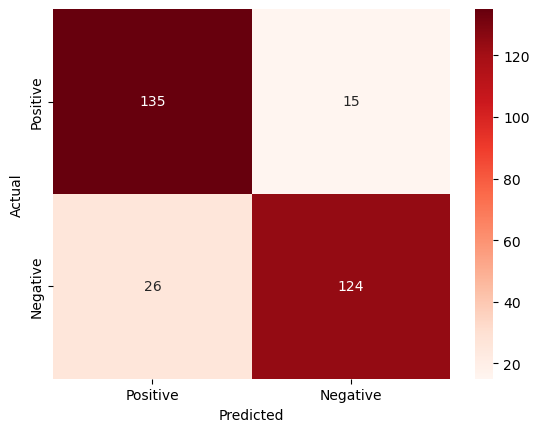

In [219]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_predict)

cm_reorder = [[cm[1,1], cm[1,0]],   # Actual Positive
                [cm[0,1], cm[0,0]]]    # Actual Negative

plt.figure()
sns.heatmap(cm_reorder, annot=True, fmt='d', cmap='Reds', xticklabels=["Positive", "Negative"], yticklabels=["Positive", "Negative"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

#### 4aiii

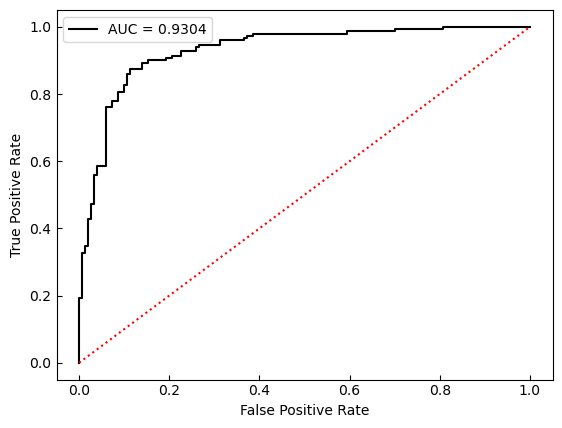

In [220]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_test_scores)
auc = roc_auc_score(y_test, y_test_scores)

plt.figure()
plt.tick_params(axis='both',direction='in')
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", color = 'black')
plt.plot([0,1], [0,1], color = 'red', linestyle='dotted')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("ROC_Curve.png", dpi=300, bbox_inches="tight")
plt.show()

#### 4aiv

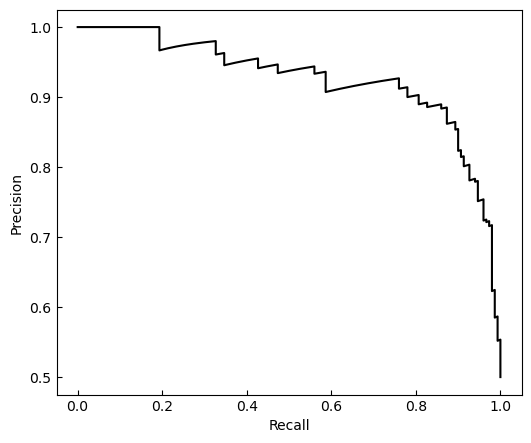

In [221]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_test_scores)

plt.figure(figsize=(6,5))
plt.tick_params(axis='both',direction='in')
plt.plot(recall, precision, color = 'black')
plt.xlabel("Recall")
plt.ylabel("Precision")
# plt.title("Precision-Recall Curve")
plt.savefig("PR_Curve.png", dpi=300, bbox_inches="tight")
plt.show()

#### 4b

In [222]:
x_trainvalidation = pd.concat([x_train, x_validation])
y_trainvalidation = pd.concat([y_train, y_validation])

In [223]:
x_trainvalidation_tfidf = tfidf.fit_transform(x_trainvalidation)

In [224]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=30)

cv_results = cross_validate(best_model, x_trainvalidation_tfidf,y_trainvalidation,cv=cv,scoring=['f1', 'roc_auc'])

In [225]:
print("Average CV F1:", cv_results['test_f1'].mean())
print("Stdev CV F1:", cv_results['test_f1'].std())

print("Average CV AUC:", cv_results['test_roc_auc'].mean())
print("Stdev CV AUC:", cv_results['test_roc_auc'].std())

Average CV F1: 0.8419386196438057
Stdev CV F1: 0.015103291496632303
Average CV AUC: 0.9170726643598617
Stdev CV AUC: 0.013283278689778605


#### 4cii

In [230]:
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, roc_auc_score

embedding_svm = LinearSVC(penalty="l2", C=1.0, dual=False, max_iter=5000, random_state=30)

embedding_svm.fit(x_train_emb, y_train)

y_validation_emb_predict = embedding_svm.predict(x_val_emb)
y_validation_emb_scores = embedding_svm.decision_function(x_val_emb)

emb_validation_f1 = f1_score(y_validation, y_validation_emb_pred)
emb_validation_auc = roc_auc_score(y_validation, y_validation_emb_scores)

print("Embedding Validation F1:", emb_validation_f1)
print("Embedding Validation AUC-ROC:", emb_validation_auc)

Embedding Validation F1: 0.711864406779661
Embedding Validation AUC-ROC: 0.7771111111111111
